In [19]:
from bs4 import BeautifulSoup
import urllib
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings

import numpy as np
import statsmodels.api as sm
import scipy.stats as st
import pandas as pd


import requests, sys, json, re
sys.path.insert(1, '../scripts/') # comment out in python script
from load_environmental_variables import *

In [6]:
# polyA tail lengths
polyA_1 = pd.read_excel(local_data_path + 'raw/41592_2019_503_MOESM6_ESM.xlsx', sheet_name = 0, 
                        skiprows=list(range(2)), index_col = 0)
polyA_2 = pd.read_excel(local_data_path + 'raw/41592_2019_503_MOESM6_ESM.xlsx', sheet_name = 1, 
                        skiprows=list(range(2)), index_col = 0)
polyA = pd.DataFrame(index = sorted(set(polyA_1.index.tolist() + polyA_2.index.tolist()))) 
polyA['HeLA_median'] = polyA.index.map(dict(zip(polyA_1.index.tolist(), polyA_1.gene_median_polyA_length.tolist())))
polyA['iPSC_median'] = polyA.index.map(dict(zip(polyA_2.index.tolist(), polyA_2.iPSC_median_polyA_length.tolist())))
polyA['Organoid_median'] = polyA.index.map(dict(zip(polyA_2.index.tolist(), polyA_2.Org_median_polyA_length.tolist())))
polyA['MEAN'] = polyA.mean(axis = 1)
polyA['SD'] = np.sqrt(polyA.loc[:, ['HeLA_median', 'iPSC_median', 'Organoid_median']].var(axis = 1))
polyA.to_csv(local_data_path + 'processed/polyA_length.csv')


# MANE SELECTED transcripts and protein sequences
ids = pd.read_csv(local_data_path + 'raw/MANE.GRCh38.v0.9.summary.txt', sep = '\t')

psim_me = ids.loc[:, ['Ensembl_Gene', 'HGNC_ID', '#NCBI_GeneID', 'Ensembl_nuc', 'Ensembl_prot', 'symbol', 'name', 'chr_strand']]
psim_me.columns = ['ENSG_ID', 'HGNC_ID', 'NCBI_ID', 'ENST_ID', 'ENSP_ID', 'GENE_SYMBOL', 'GENE_NAME', 'CHR_STRAND']

psim_me['POLYA_LENGTH'] = psim_me.GENE_SYMBOL.map(dict(zip(polyA.index.tolist(), polyA.MEAN.tolist())))

In [7]:
# get all scipy.stats distributions
hyperlink = 'https://docs.scipy.org/doc/scipy/reference/stats.html'
document= BeautifulSoup(urllib.request.urlopen(hyperlink).read()).get_text()
a = document.index('alpha(*args,\xa0**kwds)')
b = document.index('A wrapped Cauchy continuous random variable.')
dist_names = document[a:b].splitlines()[::3]
dist_names = [i.split('(')[0] for i in dist_names]

In [14]:
# fit best distribution
# code adapted from 
# https://stackoverflow.com/questions/37487830/how-to-find-probability-distribution-and-parameters-for-real-data-python-3
# https://stackoverflow.com/questions/6620471/fitting-empirical-distribution-to-theoretical-ones-with-scipy-python/16651955#16651955

# def get_distribution_fit(data, dist_names, bins = 200):
# #     dist_names = ["norm", "exponweib", "weibull_max", "weibull_min", "pareto", "genextreme", 
# #                  'gamma', 'beta', 'rayleigh', 'pareto']
    
#     distribution_df = pd.DataFrame(columns = ['KS D statistic', 'KS p-value', 'SSE'])
#     counter = 0
#     for dist_name in dist_names:
#         print(counter)
#         try:
#             with warnings.catch_warnings():
#                 warnings.filterwarnings('ignore')
                
#             distribution = getattr(st, dist_name)
#             params = distribution.fit(data)
#             y, x = np.histogram(data, bins=bins, density=True)
#             x = (x + np.roll(x, -1))[:-1] / 2.0


#             D, p = st.kstest(data, dist_name, args=params)

#             # Separate parts of parameters
#             arg = params[:-2]
#             loc = params[-2]
#             scale = params[-1]

#             # Calculate fitted PDF and error with fit in distribution
#             pdf = distribution.pdf(x, loc=loc, scale=scale, *arg)
#             sse = np.sum(np.power(y - pdf, 2.0))

#             distribution_df.loc[dist_name, :] = [D, p, sse]
#         except:
#             distribution_df.loc[dist_name, :] = [float('nan')]*3
#         counter += 1
#     return distribution_df

# distribution_df = get_distribution_fit(polyA.MEAN, dist_names = dist_names[:60] + dist_names[61:70] + dist_names[71:])
# distribution_df.to_csv(local_data_path + 'processed/polyA_distribution_fits.csv')
distribution_df = pd.read_csv(local_data_path + 'processed/polyA_distribution_fits.csv', index_col = 0)

In [9]:
distribution_df[distribution_df['SSE'] == distribution_df['SSE'].min()].index.tolist()

['johnsonsu']

In [10]:
distribution_df[distribution_df['KS p-value'] == distribution_df['KS p-value'].max()].index.tolist()

['johnsonsu']

In [15]:
def make_pdf(dist, params, size=10000):
    """Generate distributions's Probability Distribution Function """

    # Separate parts of parameters
    arg = params[:-2]
    loc = params[-2]
    scale = params[-1]

    # Get sane start and end points of distribution
    start = dist.ppf(0.01, *arg, loc=loc, scale=scale) if arg else dist.ppf(0.01, loc=loc, scale=scale)
    end = dist.ppf(0.99, *arg, loc=loc, scale=scale) if arg else dist.ppf(0.99, loc=loc, scale=scale)

    # Build PDF and turn into pandas Series
    x = np.linspace(start, end, size)
    y = dist.pdf(x, loc=loc, scale=scale, *arg)
    pdf = pd.Series(y, x)

    return pdf
pdf = make_pdf(st.johnsonsu,st.johnsonsu.fit(polyA.MEAN) )

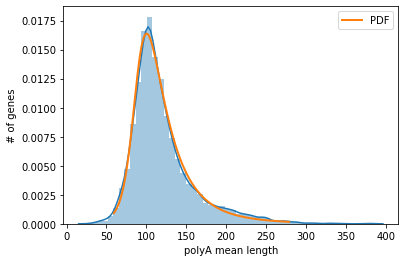

In [16]:
fig, ax = plt.subplots()
g= sns.distplot(polyA.MEAN, ax = ax, kde = True)
ax.set_xlabel('polyA mean length')
ax.set_ylabel('# of genes')
pdf.plot(lw=2, label='PDF', legend=True);

In [ ]:
# SCRIPT FOR PYTHON

In [22]:
import numpy as np
import statsmodels.api as sm
import scipy.stats as st
import pandas as pd

import requests, sys, json, re
sys.path.insert(1, '../scripts/') # comment out in python script
from load_environmental_variables import *

polyA = pd.read_csv(local_data_path + 'processed/polyA_length.csv', index_col = 0)

# polyA polyA_params
polyA = pd.read_csv(local_data_path + 'processed/polyA_length.csv', index_col = 0)
polyA_params = st.johnsonsu.fit(polyA.MEAN)
idx = sorted(set(polyA.SD.dropna().index.tolist()).intersection(polyA.MEAN.dropna().index.tolist()))
reg_data = polyA.loc[idx, ['SD', 'MEAN']]
X = sm.add_constant(reg_data.MEAN, prepend = False)
polyA_mod = sm.OLS(reg_data.SD, X).fit()
min_polyA_mean = -polyA_mod.params['const']/polyA_mod.params['MEAN']

In [ ]:
# END SCRIPT FOR PYTHON

In [24]:
polyA_mod.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     SD   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     1352.
Date:                Thu, 09 Jul 2020   Prob (F-statistic):          1.59e-251
Time:                        00:56:16   Log-Likelihood:                -15289.
No. Observations:                3590   AIC:                         3.058e+04
Df Residuals:                    3588   BIC:                         3.059e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
MEAN           0.4237      0.012     36.775      0.000       0.401       0.446
const        -21.5952      1.320    -16.357      0.000     -24.184     -19.007
==============================================================================
Omnibus:                      977.001   Durbin-Watson:                   1.981
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5774.014
Skew:                           1.161   Prob(JB):                         0.00
Kurtosis:                       8.763   Cond. No.                         530.
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

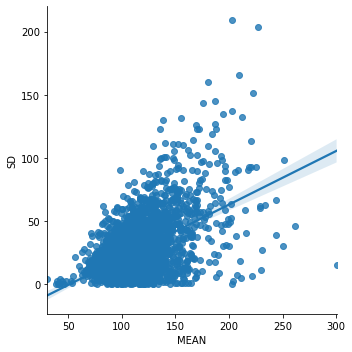

In [25]:
sns.lmplot(y = 'SD', x = 'MEAN', data = reg_data)